# Figure 3: Batch Effects



## Shared Setup

General setup loads required libraries, batch-effect inputs, and shared plotting/export conventions.



In [6]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
  library(forcats)
  library(fs)
  library(jsonlite)
  library(purrr)
  library(scales)
  library(viridis)
  library(arrow)
  library(patchwork)
  library(grid)
})

find_config_path <- function() {
  env_path <- Sys.getenv("CONFIG_PATH", unset = "")
  if (nzchar(env_path) && file.exists(env_path)) {
    return(normalizePath(env_path, winslash = "/", mustWork = TRUE))
  }

  d <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
  repeat {
    cand <- file.path(d, "config.json")
    if (file.exists(cand)) {
      return(normalizePath(cand, winslash = "/", mustWork = TRUE))
    }
    parent <- dirname(d)
    if (identical(parent, d)) break
    d <- parent
  }

  stop("Could not locate config.json. Set CONFIG_PATH or launch Jupyter from within the project tree.")
}

config_path <- find_config_path()
config <- jsonlite::fromJSON(config_path)
project_root <- normalizePath(config$project_root, winslash = "/", mustWork = FALSE)

plot_style_file <- fs::path(project_root, "scripts", "utils", "plot_style.R")
if (!file_exists(plot_style_file)) stop("Missing plot style helper: ", plot_style_file)
source(plot_style_file)
plot_style <- get_plot_style(config)
font_family_use <- get_export_font_family()

figure3_dir <- fs::path(project_root, "figures", "Figure3")
fs::dir_create(figure3_dir, recurse = TRUE)
fs::dir_create(fs::path(figure3_dir, "panels"), recurse = TRUE)

figure_width_mm <- 220
figure_height_max_mm <- 210
figure_width_in <- figure_width_mm / 25.4

panel_width_mm <- 88
panel_width_in <- panel_width_mm / 25.4
panel_height_in <- panel_width_in * 0.96
# Target relative tile height in Panel A; < 1 shortens cells vertically.
heatmap_tile_height <- 1.00
# Lower this to make Panel A (heatmap) less tall while keeping rows contiguous.
heatmap_height_scale <- 0.58
heatmap_height_in <- panel_height_in * heatmap_height_scale

# Export dimensions for individual panels. B and C match combined layout (half-width bottom row).
# Panel A uses a taller standalone height so x-axis labels don't overlap when saved alone.
panel_export_width_a_in <- figure_width_in
panel_export_height_a_in <- 4
panel_export_width_bc_in <- figure_width_in / 2
panel_export_height_bc_in <- panel_height_in

axis_title_pt <- 7
axis_text_pt <- 6
plot_title_pt <- 7
legend_title_pt <- 6
legend_text_pt <- 6
panel_tag_pt <- 7

qc_target <- "no_quality"
metrics_keep <- c("DKI_mkt", "NODDI_icvf", "MAPMRI_rtop", "GQI_fa", "GQI_md")

metric_labels <- c(
  "DKI_mkt" = "MKT",
  "NODDI_icvf" = "ICVF",
  "MAPMRI_rtop" = "RTOP",
  "GQI_fa" = "FA",
  "GQI_md" = "MD"
)

# Reuse the shared project metric color dictionary from plot_style.R.
metric_colors <- metric_colors[unname(metric_labels)]
if (any(is.na(metric_colors))) {
  stop("Missing metric colors for: ", paste(names(metric_colors)[is.na(metric_colors)], collapse = ", "))
}

category_order <- c(
  "Association",
  "Projection (Basal Ganglia)",
  "Projection (Brainstem)",
  "Cerebellum",
  "Commissure"
)

# --- TEMP: batch vs vendor for Panels A/B heatmap + line only ---
# TRUE  = load pooled batch_effects from assemble_batch_effects.R
# FALSE = load vendor_effects as before
FIGURE3_USE_BATCH_EFFECTS <- TRUE
figure3_effect_tag <- if (FIGURE3_USE_BATCH_EFFECTS) "batch_effect" else "vendor_effect"

if (FIGURE3_USE_BATCH_EFFECTS) {
  batch_effects_rds <- fs::path(project_root, "data", "batch_effects", "batch_effects_all_outputs.rds")
  if (!file_exists(batch_effects_rds)) {
    stop("FIGURE3_USE_BATCH_EFFECTS is TRUE but file not found: ", batch_effects_rds,
         "\nRun assemble_batch_effects.R after calculate_batch_effects.R")
  }
  df_vendor_all <- readRDS(batch_effects_rds)
  if (!is.data.frame(df_vendor_all)) stop("batch_effects file is not a data.frame: ", batch_effects_rds)
  if ("output_type" %in% names(df_vendor_all)) {
    df_vendor_all <- df_vendor_all %>% filter(output_type == "batch_effects")
  }
  if (nrow(df_vendor_all) == 0) {
    stop("No pooled batch_effects rows in ", batch_effects_rds)
  }
  message("[Figure3] Using batch_effects (pooled), n = ", nrow(df_vendor_all))
} else {
  assembled_vendor_files <- c(
    fs::path(project_root, "data", "vendor_effects", "vendor_effects_all_outputs.rds"),
    fs::path(project_root, "data", "vendor_effects", "vendor_effects_pairwise_all_outputs.rds")
  )
  assembled_vendor_file <- assembled_vendor_files[file_exists(assembled_vendor_files)][1]

  vendor_dirs <- c(
    fs::path(project_root, "data", "vendor_effects", "vendor_effects_outputs"),
    fs::path(project_root, "data", "vendor_effects", "vendor_effects_outputs_pairwise")
  )
  vendor_dir <- vendor_dirs[dir_exists(vendor_dirs)][1]

  if (!is.na(assembled_vendor_file) && nzchar(assembled_vendor_file)) {
    df_vendor_all <- readRDS(assembled_vendor_file)
    if (!is.data.frame(df_vendor_all)) {
      stop("Assembled batch effects file is not a data.frame: ", assembled_vendor_file)
    }
  } else {
    message("[WARN] Assembled batch effects file not found. Falling back to file scan.")
    if (is.na(vendor_dir) || !nzchar(vendor_dir)) {
      stop("Batch effects directory not found. Checked: ", paste(vendor_dirs, collapse = ", "))
    }
    vendor_files <- list.files(vendor_dir, pattern = "_vendor_effects\\.rds$", full.names = TRUE)
    if (length(vendor_files) == 0) {
      stop("No _vendor_effects.rds files found in ", vendor_dir)
    }
    df_vendor_all <- purrr::map_dfr(vendor_files, readRDS)
  }
}

required_vendor_cols <- c("source", "qc_covariate", "metric", "bundle", "bundle_category", "effect_size")
if (!all(required_vendor_cols %in% names(df_vendor_all))) {
  stop("Assembled batch effect data missing required columns: ",
       paste(setdiff(required_vendor_cols, names(df_vendor_all)), collapse = ", "))
}

make_panel_theme <- function(legend_position = "none", placed_width_in = panel_width_in) {
  make_theme_pub(
    style = plot_style,
    legend_position = legend_position,
    axis_title_pt = pt_for_export(axis_title_pt, placed_width_in, placed_width_in),
    axis_text_pt = pt_for_export(axis_text_pt, placed_width_in, placed_width_in),
    plot_title_pt = pt_for_export(plot_title_pt, placed_width_in, placed_width_in),
    legend_title_pt = pt_for_export(legend_title_pt, placed_width_in, placed_width_in),
    legend_text_pt = pt_for_export(legend_text_pt, placed_width_in, placed_width_in),
    base_size_pt = 11
  ) +
    theme(text = element_text(family = font_family_use))
}

# save_plot_outputs() from plot_style.R; pass out_dir = figure3_dir

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)






[Figure3] Using batch_effects (pooled), n = 170748



## Panel A (Top Row): Unharmonized batch-effect heatmap

Heatmap of unharmonized batch effects (`qc_covariate = no_quality`) for the five primary microstructural metrics, using the existing heatmap style.



[WARN] Right-lateralized superior cerebellar peduncle not available in panel A; using: SuperiorCerebellarPeduncle



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_a_vendor_effect_heatmap.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_a_vendor_effect_heatmap.png



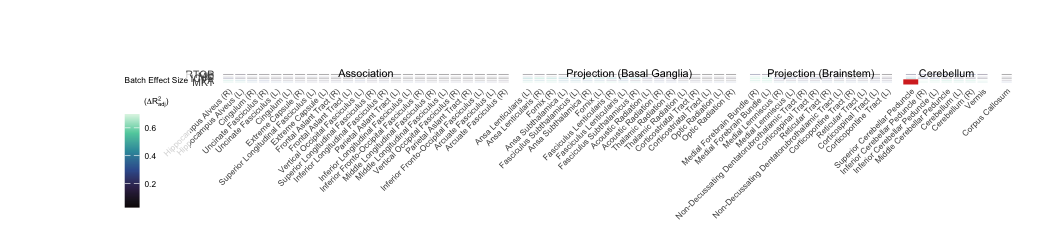

In [7]:
df_heat <- df_vendor_all %>%
  filter(
    source == "raw",
    qc_covariate == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle), !is.na(bundle_category), !is.na(effect_size)
  ) %>%
  mutate(
    metric_label = unname(metric_labels[metric]),
    bundle_clean = bundle,
    bundle_category = case_when(
      bundle_category == "ProjectionBasalGanglia" ~ "Projection (Basal Ganglia)",
      bundle_category == "ProjectionBrainstem" ~ "Projection (Brainstem)",
      TRUE ~ bundle_category
    ),
    bundle_clean = bundle_clean %>%
      str_replace("FrontoOccipital", "Fronto-Occipital") %>%
      str_replace("NonDecussating", "Non-Decussating") %>%
      str_replace("L$", " (L)") %>%
      str_replace("R$", " (R)") %>%
      str_replace_all("(?<=[a-z])(?=[A-Z])", " ")
  )

if (nrow(df_heat) == 0) stop("No rows for Panel A (raw + no_quality + metrics_keep)")

metric_order <- df_heat %>%
  group_by(metric_label) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(mean_effect)) %>%
  pull(metric_label)

df_heat$metric_label <- factor(df_heat$metric_label, levels = metric_order)

bundle_df <- df_heat %>%
  group_by(bundle_category, bundle_clean) %>%
  summarise(mean_effect = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  mutate(bundle_category = factor(bundle_category, levels = category_order)) %>%
  arrange(bundle_category, desc(mean_effect), bundle_clean)

bundle_levels <- c()
for (cat in category_order) {
  cat_bundles <- bundle_df %>% filter(bundle_category == cat) %>% pull(bundle_clean)
  if (length(cat_bundles) > 0) {
    bundle_levels <- c(bundle_levels, cat_bundles, paste0("spacer_", cat))
  }
}
bundle_levels <- bundle_levels[!grepl("^spacer_Commissure$", bundle_levels)]

df_heat$bundle_clean <- factor(df_heat$bundle_clean, levels = bundle_levels)

highlight_bundle_patterns <- c(
  "Cerebellum_SuperiorCerebellarPeduncleR",
  "SuperiorCerebellarPeduncleR",
  "Cerebellum_SuperiorCerebellarPeduncle",
  "SuperiorCerebellarPeduncle"
)
highlight_bundle_pattern <- highlight_bundle_patterns[
  vapply(highlight_bundle_patterns, function(pat) any(str_detect(df_heat$bundle, fixed(pat))), logical(1))
][1]
if (is.na(highlight_bundle_pattern) || !nzchar(highlight_bundle_pattern)) {
  warning("Panel A highlight cell not found for superior cerebellar peduncle")
  highlight_cell <- df_heat[0, c("bundle_clean", "metric_label")]
} else {
  if (!str_detect(highlight_bundle_pattern, "SuperiorCerebellarPeduncleR")) {
    message("[WARN] Right-lateralized superior cerebellar peduncle not available in panel A; using: ", highlight_bundle_pattern)
  }
  highlight_cell <- df_heat %>%
    filter(metric == "DKI_mkt", str_detect(bundle, fixed(highlight_bundle_pattern))) %>%
    distinct(bundle_clean, metric_label)
}

spacer_df <- expand.grid(
  bundle_clean = bundle_levels[grepl("^spacer_", bundle_levels)],
  metric_label = metric_order
) %>%
  mutate(effect_size = NA_real_)

df_heat_plot <- bind_rows(
  df_heat %>% select(bundle_clean, metric_label, effect_size),
  spacer_df
)

x_labels <- levels(df_heat_plot$bundle_clean)
x_labels[grepl("^spacer_", x_labels)] <- ""

bundle_index_df <- tibble(bundle_clean = bundle_levels, index = seq_along(bundle_levels))
cat_positions <- bundle_df %>%
  group_by(bundle_category) %>%
  summarise(
    xmin = min(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmax = max(bundle_index_df$index[bundle_index_df$bundle_clean %in% bundle_clean]),
    xmid = mean(c(xmin, xmax)),
    .groups = "drop"
  ) %>%
  filter(bundle_category != "Commissure")

heatmap_export_width_in <- figure_width_in
heatmap_final_width_in <- figure_width_in

p_panel_a <- ggplot(df_heat_plot, aes(x = bundle_clean, y = metric_label, fill = effect_size)) +
  geom_tile(color = "white", linewidth = 0.45, height = heatmap_tile_height) +
  geom_tile(data = highlight_cell, aes(x = bundle_clean, y = metric_label), fill = NA, color = "#D73027", linewidth = 0.9, width = 0.98, height = heatmap_tile_height, inherit.aes = FALSE) +
  scale_fill_viridis_c(
    option = "mako",
    name = expression(atop("Batch Effect Size", "(" * Delta * R[adj]^2 * ")")),
    na.value = "white"
  ) +
  guides(fill = guide_colorbar(barheight = unit(length(metric_order) * heatmap_tile_height * 0.78, "lines"), barwidth = unit(0.62, "lines"))) +
  scale_x_discrete(labels = x_labels, expand = expansion(add = 0.8)) +
  scale_y_discrete(expand = expansion(mult = c(0, 0))) +
  coord_cartesian(clip = "off") +
  labs(x = NULL, y = NULL) +
  theme_minimal(
    base_family = font_family_use,
    base_size = pt_for_export(axis_text_pt, heatmap_export_width_in, heatmap_final_width_in)
  ) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    axis.text.y = element_text(size = pt_for_export(axis_text_pt + 0.2, heatmap_export_width_in, heatmap_final_width_in)),
    axis.ticks = element_blank(),
    plot.margin = margin(44, 14, 6, 112),
    legend.title = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    legend.text = element_text(size = pt_for_export(5, heatmap_export_width_in, heatmap_final_width_in)),
    legend.position = c(-0.12, 0.97),
    legend.justification = c(0, 1),
    legend.direction = "vertical",
    legend.margin = margin(1, 1, 1, 1),
    legend.background = element_rect(fill = scales::alpha("white", 0.76), color = NA),
    legend.box.background = element_blank(),
    panel.background = element_rect(fill = plot_style$panel_background_fill, color = NA),
    plot.background = element_rect(fill = plot_style$plot_background_fill, color = NA),
    panel.border = element_blank()
  )

y_top <- length(metric_order) + 0.82
for (i in seq_len(nrow(cat_positions))) {
  p_panel_a <- p_panel_a + annotate(
    "text",
    x = cat_positions$xmid[i],
    y = y_top,
    label = cat_positions$bundle_category[i],
    family = font_family_use,
    size = pt_for_export(axis_text_pt + 0.5, heatmap_export_width_in, heatmap_final_width_in) / .pt
  )
}

options(repr.plot.width = figure_width_in, repr.plot.height = heatmap_height_in, repr.plot.res = 120)

p_panel_a
save_plot_outputs(
  p_panel_a,
  "Figure3_panel_a_vendor_effect_heatmap",
  fs::path(figure3_dir, "panels"),
  panel_export_width_a_in,
  panel_export_height_a_in,
  pdf_family = font_family_use,
  allow_sans_fallback = FALSE
)



## Panel B (Bottom Left): Effects before vs after harmonization (batch)

Same data source as Panel A (`FIGURE3_USE_BATCH_EFFECTS`: pooled batch effects vs. assembled legacy outputs). Line plot of mean batch effects across bundles; inset zoom near harmonized cluster. **Error bars = SEM.** Exports as `Figure3_panel_b_batch_effect_lineplot` or `..._vendor_effect_lineplot` (filename tag reflects `figure3_effect_tag`).



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_b_vendor_effect_lineplot.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_b_vendor_effect_lineplot.png



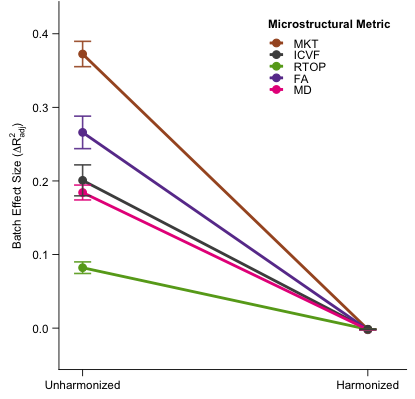

In [8]:
df_line <- df_vendor_all %>%
  filter(
    source %in% c("raw", "harmonized"),
    qc_covariate == qc_target,
    metric %in% metrics_keep,
    !is.na(bundle),
    !is.na(effect_size)
  ) %>%
  group_by(source, metric, bundle) %>%
  summarise(effect_size = mean(effect_size, na.rm = TRUE), .groups = "drop") %>%
  group_by(source, metric) %>%
  summarise(
    mean_effect = mean(effect_size, na.rm = TRUE),
    n_bundle = dplyr::n(),
    sem_effect = if_else(n_bundle > 1, sd(effect_size, na.rm = TRUE) / sqrt(n_bundle), as.numeric(NA)),
    .groups = "drop"
  ) %>%
  mutate(
    source = factor(source, levels = c("raw", "harmonized"), labels = c("Unharmonized", "Harmonized")),
    metric_label = factor(recode(metric, !!!metric_labels), levels = unname(metric_labels)),
    source_num = as.numeric(source)
  )

if (nrow(df_line) == 0) stop("No rows for Panel B")

y_limits <- range(
  c(df_line$mean_effect - df_line$sem_effect, df_line$mean_effect + df_line$sem_effect),
  na.rm = TRUE,
  finite = TRUE
)
if (!all(is.finite(y_limits))) y_limits <- c(0, 0.05)
y_pad <- max(diff(y_limits) * 0.08, 0.004)
y_limits <- c(min(0, y_limits[1] - y_pad), y_limits[2] + y_pad)

panel_b_theme <- make_panel_theme(legend_position = c(0.98, 0.98), placed_width_in = panel_width_in)

p_line_main <- ggplot(df_line, aes(x = source_num, y = mean_effect, group = metric_label, color = metric_label)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.8) +
  geom_errorbar(aes(ymin = mean_effect - sem_effect, ymax = mean_effect + sem_effect), width = 0.06, linewidth = 0.45, alpha = 0.9) +
  scale_color_manual(values = metric_colors, name = "Microstructural Metric", drop = FALSE) +
  guides(color = guide_legend(ncol = 1, byrow = TRUE)) +
  scale_x_continuous(
    breaks = c(1, 2),
    labels = c("Unharmonized", "Harmonized"),
    expand = expansion(mult = c(0.05, 0.1))
  ) +
  coord_cartesian(ylim = y_limits) +
  labs(
    x = NULL,
    y = expression("Batch Effect Size (" * Delta * R[adj]^2 * ")")
  ) +
  panel_b_theme +
  theme(
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    panel.grid.minor = element_blank(),
    legend.justification = c(1, 1),
    legend.direction = "vertical",
    legend.background = element_blank(),
    legend.box.background = element_blank(),
    legend.key.height = unit(7, "pt"),
    legend.key.width = unit(10, "pt"),
    axis.title = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    axis.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    legend.title = element_text(face = "bold", size = pt_for_export(7, panel_width_in, panel_width_in)),
    legend.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in)),
    plot.title = element_blank(),
    plot.margin = margin(1, 5.5, 5.5, 5.5)
  )

p_panel_b <- p_line_main

options(repr.plot.width = panel_width_in, repr.plot.height = panel_height_in, repr.plot.res = 120)

p_panel_b
save_plot_outputs(
  p_panel_b,
  "Figure3_panel_b_vendor_effect_lineplot",
  fs::path(figure3_dir, "panels"),
  panel_export_width_bc_in,
  panel_export_height_bc_in
)



## Panel C: Age GAM(M) fits by vendor — unharmonized vs harmonized

**This panel is the default Panel C in the combined ABC figure below;** the boxplot Panel C remains available as `p_panel_c`. Uses **DKI_mkt (MKT)** for the SCP bundle column. Predictions are **cached** as `Figure3_panel_c_gam_age_by_vendor_mkt_cache.rds`. Export: `Figure3_panel_c_gam_age_by_vendor_mkt_2row`.

Layout is **two rows** (Unharmonized on top, Harmonized below), **single column**, lines **colored by vendor**.


[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_c_gam_age_by_vendor_mkt_2row.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/panels/Figure3_panel_c_gam_age_by_vendor_mkt_2row.png



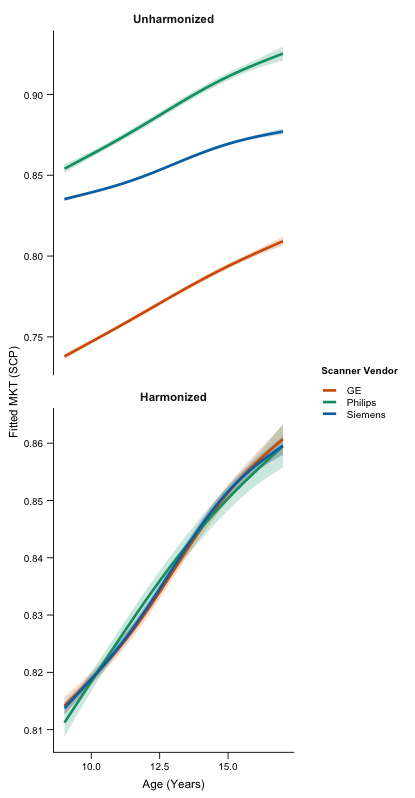

In [9]:
# --- Panel C alternative: age curves by vendor (unharmonized vs harmonized), cached -----------------------------
if (!requireNamespace("mgcv", quietly = TRUE)) {
  stop("Panel C GAM panel requires package 'mgcv'.")
}

panel_c_gam_cache <- fs::path(figure3_dir, "Figure3_panel_c_gam_age_by_vendor_mkt_cache.rds")

safe_num <- function(x) {
  x <- suppressWarnings(as.numeric(x))
  x[is.nan(x)] <- NA_real_
  x
}

# Wide-table paths + SCP MKT bundle column (must exist in both raw and harmonized parquets)
harm_path <- fs::path(project_root, "data", "harmonized_data", "merged_data_meisler_analyses_harmonized.parquet")
raw_path <- fs::path(project_root, "data", "raw_data", "merged_data_meisler_analyses.parquet")
if (!file_exists(harm_path)) stop("Harmonized parquet not found: ", harm_path)
if (!file_exists(raw_path)) stop("Raw parquet not found: ", raw_path)

pick_scp_mkt_median_col <- function(path) {
  cols <- names(arrow::read_parquet(path, as_data_frame = FALSE))
  cand <- cols[grepl("SuperiorCerebellarPeduncle", cols, fixed = TRUE) &
    grepl("DKI_mkt", cols, fixed = TRUE) &
    grepl("_median$", cols)]
  if (length(cand) == 0) {
    stop("No column matching SuperiorCerebellarPeduncle + DKI_mkt + _median in ", path)
  }
  l <- cand[grepl("SuperiorCerebellarPeduncleL", cand)]
  if (length(l)) return(l[[1]])
  r <- cand[grepl("SuperiorCerebellarPeduncleR", cand)]
  if (length(r)) return(r[[1]])
  cand[[1]]
}
bundle_col <- pick_scp_mkt_median_col(harm_path)

# Build analysis frame: same bundle column as Panel C; need subject_id + age + sex for GAMM
read_for_gam <- function(path, source_label, bcol) {
  cols_need <- c("subject_id", "age", "sex", "scanner_manufacturer", bcol)
  arrow::read_parquet(path, col_select = any_of(cols_need)) %>%
    as_tibble() %>%
    transmute(
      subject_id = as.character(subject_id),
      age = safe_num(age),
      sex = factor(trimws(as.character(sex))),
      vendor = factor(case_when(
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "siemens") ~ "Siemens",
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "philips") ~ "Philips",
        str_detect(str_to_lower(as.character(scanner_manufacturer)), "ge") ~ "GE",
        TRUE ~ NA_character_
      ), levels = c("GE", "Philips", "Siemens")),
      value = safe_num(.data[[bcol]]),
      source_label = source_label
    ) %>%
    filter(!is.na(vendor), !is.na(value), !is.na(age), !is.na(sex), !is.na(subject_id)) %>%
    filter(is.finite(value), is.finite(age))
}

df_gam_raw <- read_for_gam(raw_path, "Raw", bundle_col)
df_gam_harm <- read_for_gam(harm_path, "Harmonized", bundle_col)

fit_vendor_age_curve <- function(dat, source_name) {
  # Enough rows per vendor
  dat <- dat %>%
    filter(n() >= 80, .by = vendor)
  if (nrow(dat) < 200) return(NULL)
  # Reference sex level
  sex_ref <- names(sort(table(dat$sex), decreasing = TRUE))[1]
  dat <- dat %>% filter(vendor %in% levels(vendor))
  # Try GAMM (random intercept) then fall back to GAM
  fit_gamm4 <- NULL
  if (requireNamespace("gamm4", quietly = TRUE)) {
    fit_gamm4 <- tryCatch(
      gamm4::gamm4(
        value ~ s(age, k = 4, by = vendor) + vendor + sex,
        random = ~(1 + age | subject_id),
        data = dat,
        family = gaussian()
      ),
      error = function(e) NULL
    )
  }
  mod <- NULL
  if (!is.null(fit_gamm4)) {
    mod <- fit_gamm4$gam
  } else {
    mod <- tryCatch(
      mgcv::gam(value ~ s(age, k = 4, by = vendor) + vendor + sex, data = dat, method = "REML"),
      error = function(e) NULL
    )
  }
  if (is.null(mod)) return(NULL)
  age_lo <- max(min(dat$age, na.rm = TRUE), quantile(dat$age, 0.01, na.rm = TRUE))
  age_hi <- min(max(dat$age, na.rm = TRUE), quantile(dat$age, 0.99, na.rm = TRUE))
  ages <- seq(age_lo, age_hi, length.out = 100)
  vendors <- levels(dat$vendor)
  grid <- tidyr::crossing(age = ages, vendor = vendors, sex = sex_ref)
  grid$vendor <- factor(grid$vendor, levels = levels(dat$vendor))
  grid$sex <- factor(grid$sex, levels = levels(dat$sex))
  pr <- predict(mod, newdata = grid, type = "response", se.fit = TRUE)
  grid$fit <- as.numeric(pr$fit)
  se <- as.numeric(pr$se.fit)
  # gamm4$gam predict(se.fit=TRUE) often returns NA/non-finite SE (RE not in gam object);
  # ribbon then disappears for that facet (Raw commonly). Refit plain GAM for fit+SE on grid.
  if (any(!is.finite(se))) {
    mod_gam <- tryCatch(
      mgcv::gam(value ~ s(age, k = 4, by = vendor) + vendor + sex, data = dat, method = "REML"),
      error = function(e) NULL
    )
    if (!is.null(mod_gam)) {
      pr <- predict(mod_gam, newdata = grid, type = "response", se.fit = TRUE)
      grid$fit <- as.numeric(pr$fit)
      se <- as.numeric(pr$se.fit)
    }
  }
  se[!is.finite(se)] <- 0
  grid$fit_lwr <- grid$fit - 1.96 * se
  grid$fit_upr <- grid$fit + 1.96 * se
  grid$source <- source_name
  grid
}

run_gam_cache <- function() {
  pr_raw <- fit_vendor_age_curve(df_gam_raw, "Raw")
  pr_harm <- fit_vendor_age_curve(df_gam_harm, "Harmonized")
  if (is.null(pr_raw) || is.null(pr_harm)) {
    stop("GAM fit failed for one or both sources (inspect df_gam_raw / df_gam_harm).")
  }
  pred <- bind_rows(pr_raw, pr_harm) %>%
    mutate(source = factor(source, levels = c("Raw", "Harmonized")))
  list(bundle_col = bundle_col, created = Sys.time(), pred = pred)
}

if (file_exists(panel_c_gam_cache)) {
  cache <- readRDS(panel_c_gam_cache)
  if (is.null(cache$bundle_col) || cache$bundle_col != bundle_col) {
    message("[Panel C GAM] Cache missing or bundle_col differs; refitting.")
    cache <- run_gam_cache()
    saveRDS(cache, panel_c_gam_cache)
  }
} else {
  message("[Panel C GAM] No cache found; fitting and saving: ", panel_c_gam_cache)
  cache <- run_gam_cache()
  saveRDS(cache, panel_c_gam_cache)
}

pred_panel_c_gam <- cache$pred
# Refit if cache pred lacks CI columns or any NA ribbon bounds (e.g. old gamm4-only preds)
if (!all(c("fit_lwr", "fit_upr") %in% names(pred_panel_c_gam)) ||
    any(is.na(pred_panel_c_gam$fit_lwr) | is.na(pred_panel_c_gam$fit_upr))) {
  message("[Panel C GAM] Cache pred missing/NA CI columns; refitting.")
  cache <- run_gam_cache()
  saveRDS(cache, panel_c_gam_cache)
  pred_panel_c_gam <- cache$pred
}
panel_c_gam_height_in <- panel_height_in * 2

# free_y: harmonized row gets its own (tighter) y range; raw row unchanged
# group = vendor: one ribbon polygon per vendor (avoids merged paths across vendors)
# clip = "off": patchwork squashes Panel C into panel_height_in; default clip-on trims Raw ribbon at facet boundary
p_panel_c_gam <- ggplot(pred_panel_c_gam, aes(x = age, y = fit, color = vendor, fill = vendor)) +
  geom_ribbon(aes(ymin = fit_lwr, ymax = fit_upr, group = vendor), alpha = 0.22, color = NA, na.rm = TRUE) +
  geom_line(linewidth = 0.75, na.rm = TRUE) +
  facet_wrap(~source, ncol = 1, scales = "free_y", strip.position = "top",
    labeller = labeller(source = c(Raw = "Unharmonized", Harmonized = "Harmonized"))) +
  coord_cartesian(clip = "off") +
  scale_color_manual(values = vendor_colors, name = "Scanner Vendor", drop = FALSE) +
  scale_fill_manual(values = vendor_colors, drop = FALSE, guide = "none") +
  labs(x = "Age (Years)", y = "Fitted MKT (SCP)") +
  make_panel_theme(legend_position = "right", placed_width_in = panel_width_in) +
  theme(
    axis.line = element_line(linewidth = 0.25, color = "black"),
    axis.ticks = element_line(linewidth = 0.25, color = "black"),
    panel.grid.minor = element_blank(),
    strip.background = element_blank(),
    strip.placement = "outside",
    strip.text = element_text(size = pt_for_export(7, panel_width_in, panel_width_in), face = "bold", angle = 0),
    legend.key.height = unit(6, "pt"),
    legend.key.width = unit(10, "pt"),
    plot.margin = margin(4, 5.5, 5.5, 5.5)
  )

options(repr.plot.width = panel_width_in, repr.plot.height = panel_c_gam_height_in, repr.plot.res = 120)
p_panel_c_gam
save_plot_outputs(
  p_panel_c_gam,
  "Figure3_panel_c_gam_age_by_vendor_mkt_2row",
  fs::path(figure3_dir, "panels"),
  panel_export_width_bc_in,
  panel_export_height_bc_in
)

# Combined ABC figure (next cell) uses p_panel_c_gam as Panel C by default.


## ABC Layout Preview

Preview layout with panel A full-width on top and panels B / **C (GAM age-by-vendor lines)** side-by-side on the bottom row — bottom row height is **`panel_height_in`** (same as before), so the GAM panel is compact. Standalone C export still uses a taller height for readability.



[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_combined_abc_preview.pdf

[SAVED] /Users/stevenmeisler/Documents/Penn/abcc-qsiprep/meisler_abcd_dmri/figures/Figure3/Figure3_combined_abc_preview.png



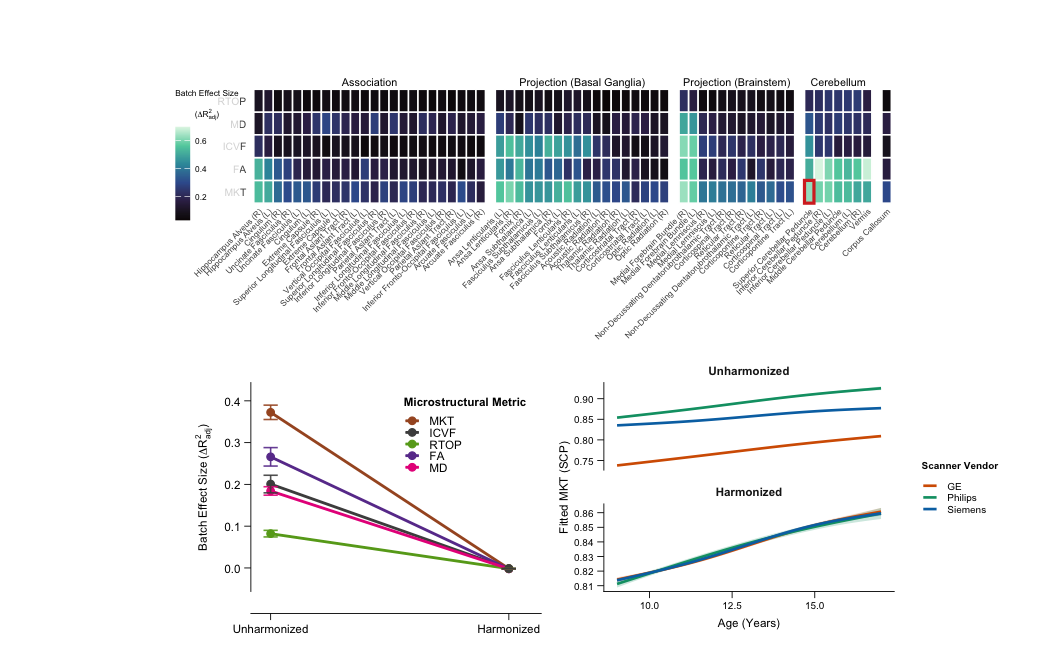

In [10]:
# Panel C = GAM lines; bottom row uses original panel_height_in so B/C match pre-GAM height (GAM facets shrink to fit)
figure3_abc <- (p_panel_a / (p_panel_b | p_panel_c_gam)) +
  patchwork::plot_layout(heights = c(heatmap_height_in, panel_height_in), widths = c(1, 1))

combined_height_in <- min(figure_height_max_mm / 25.4, heatmap_height_in + panel_height_in + 0.18)

options(repr.plot.width = figure_width_in, repr.plot.height = combined_height_in, repr.plot.res = 120)

figure3_abc
save_plot_outputs(
  figure3_abc,
  "Figure3_combined_abc_preview",
  figure3_dir,
  figure_width_in,
  combined_height_in
)

